<a href="https://www.kaggle.com/code/lalit7881/impact-of-ai-on-students-eda?scriptVersionId=319713204" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/laveshjadon/ai-impact-on-students/ai_student_impact_dataset (1).csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/laveshjadon/ai-impact-on-students/ai_student_impact_dataset (1).csv")

In [3]:
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [4]:
df.tail()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
49995,149996,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.16,High
49996,149997,STEM,Senior,2.870,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.62,Medium
49997,149998,Business,Senior,3.177,15.87,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.605,97.21,High
49998,149999,Business,Junior,3.398,19.91,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.527,84.12,Medium
49999,150000,Arts,Sophomore,3.242,3.30,Copywriting/Drafting,Beginner,1,False,3.93,2,Allowed_With_Citation,6,3.261,76.16,Low


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [6]:
df.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


In [7]:
df.isnull()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
49996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
49997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
49998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.columns

Index(['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level'],
      dtype='object')

In [11]:
df.dtypes

Student_ID                      int64
Major_Category                 object
Year_of_Study                  object
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case               object
Prompt_Engineering_Skill       object
Tool_Diversity                  int64
Paid_Subscription                bool
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy           object
Anxiety_Level_During_Exams      int64
Post_Semester_GPA             float64
Skill_Retention_Score         float64
Burnout_Risk_Level             object
dtype: object

In [12]:
df.shape

(50000, 16)

In [13]:
df.nunique()

Student_ID                    50000
Major_Category                    5
Year_of_Study                     5
Pre_Semester_GPA               2389
Weekly_GenAI_Hours             3566
Primary_Use_Case                  5
Prompt_Engineering_Skill          3
Tool_Diversity                    5
Paid_Subscription                 2
Traditional_Study_Hours        2516
Perceived_AI_Dependency          10
Institutional_Policy              3
Anxiety_Level_During_Exams       10
Post_Semester_GPA              2269
Skill_Retention_Score          5872
Burnout_Risk_Level                3
dtype: int64

## EDA

Dataset Shape : (50000, 16)

Columns:
 Index(['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level'],
      dtype='object')

Data Types:

Student_ID                      int64
Major_Category                 object
Year_of_Study                  object
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case               object
Prompt_Engineering_Skill       object
Tool_Diversity                  int64
Paid_Subscription                bool
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy           object
Anxiety_Level_During_Exams      int64
Post_Semester_GPA             floa

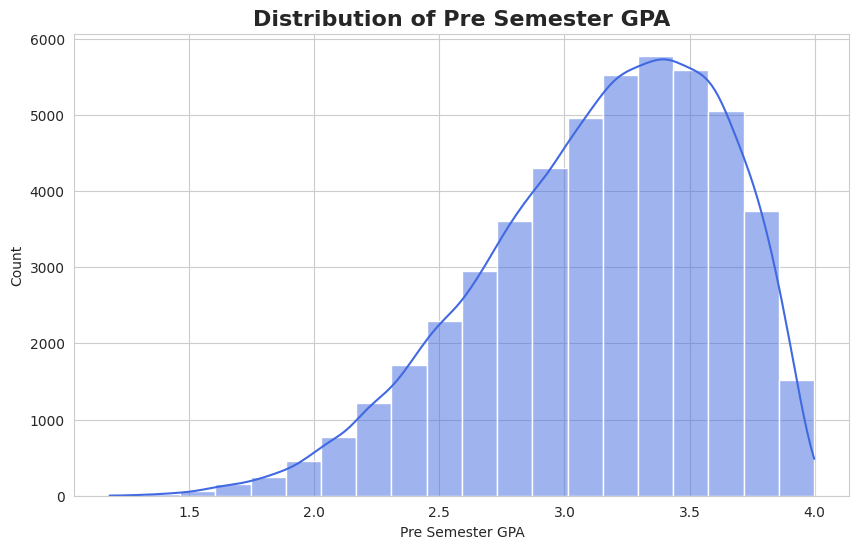

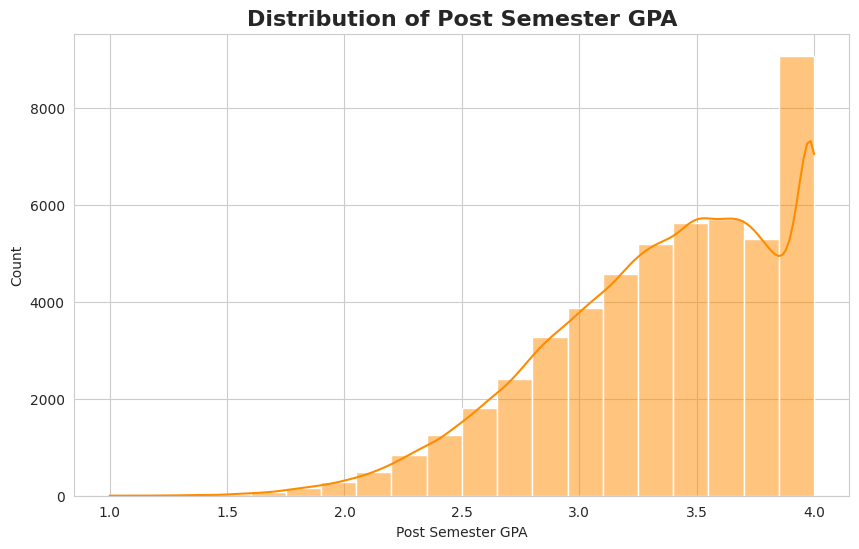

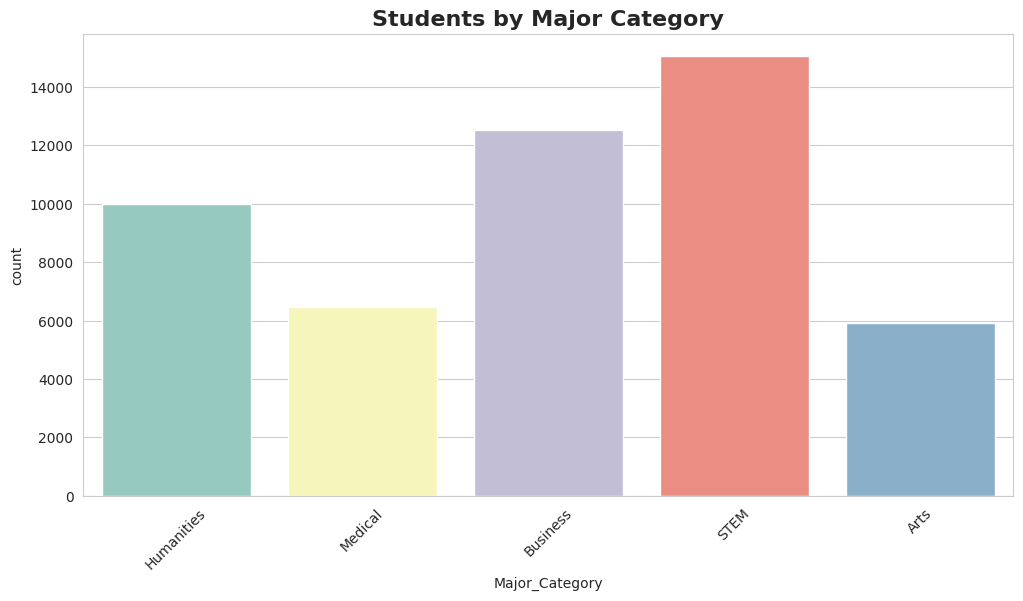

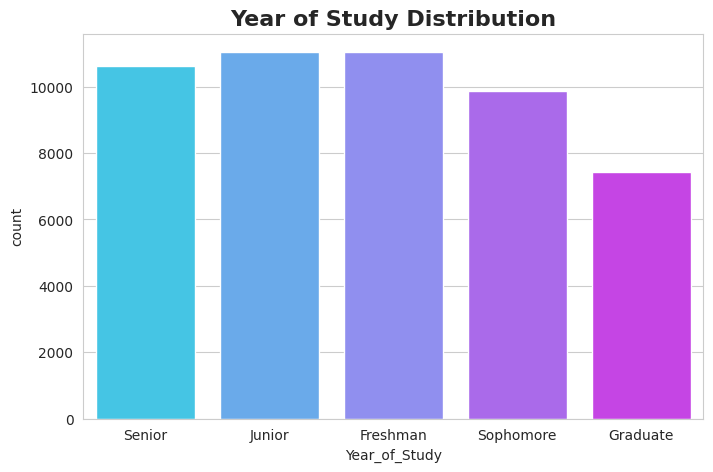

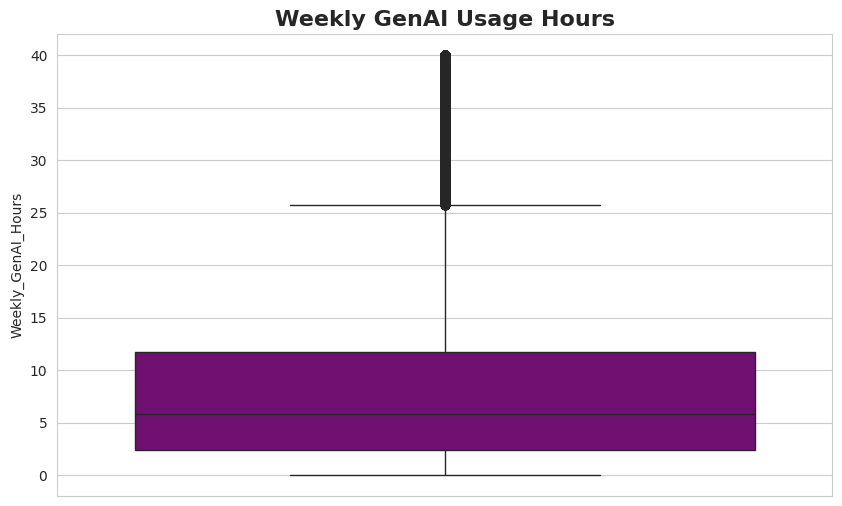

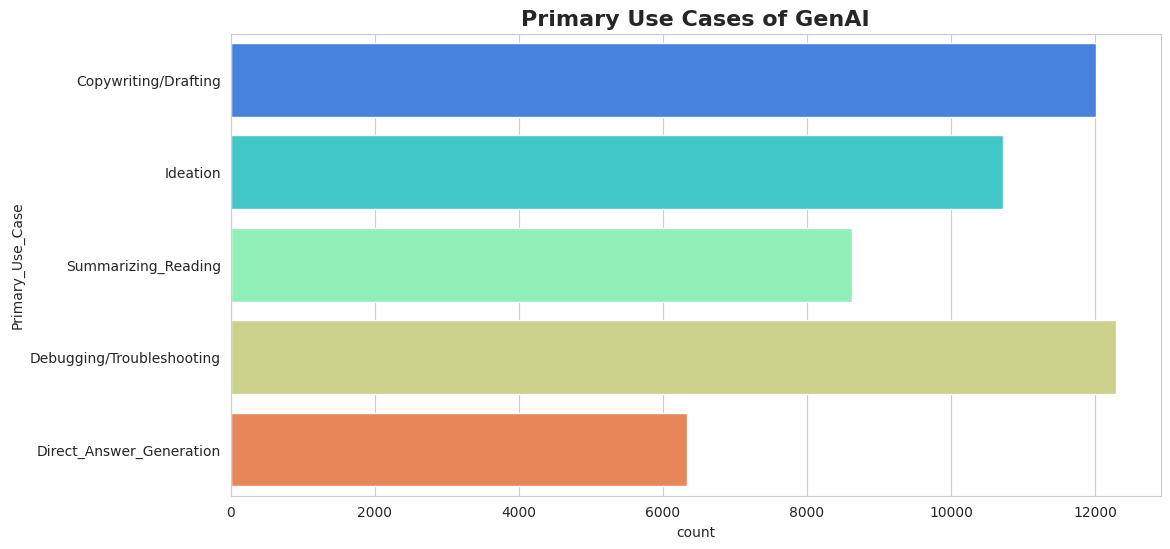

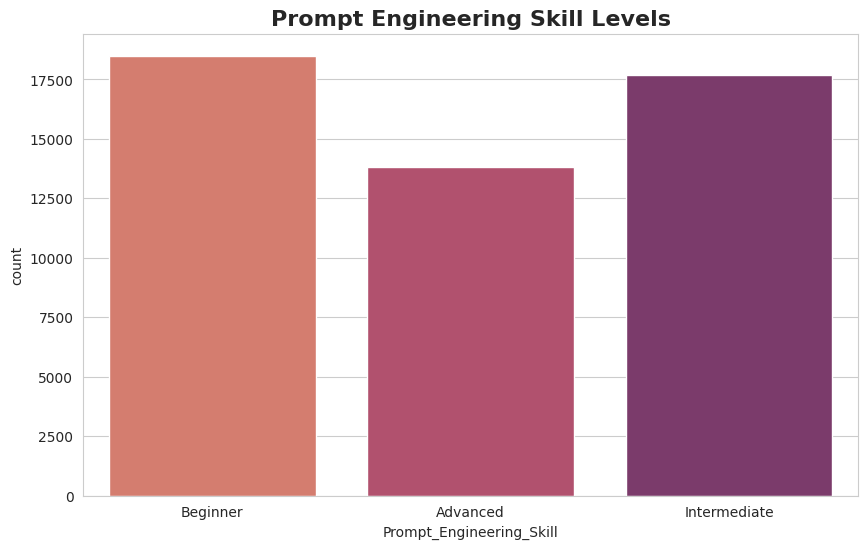

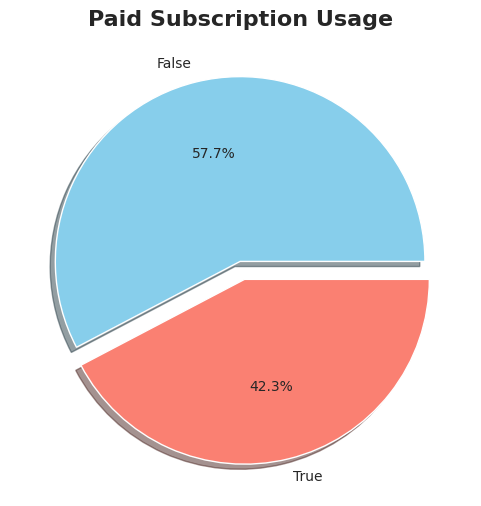

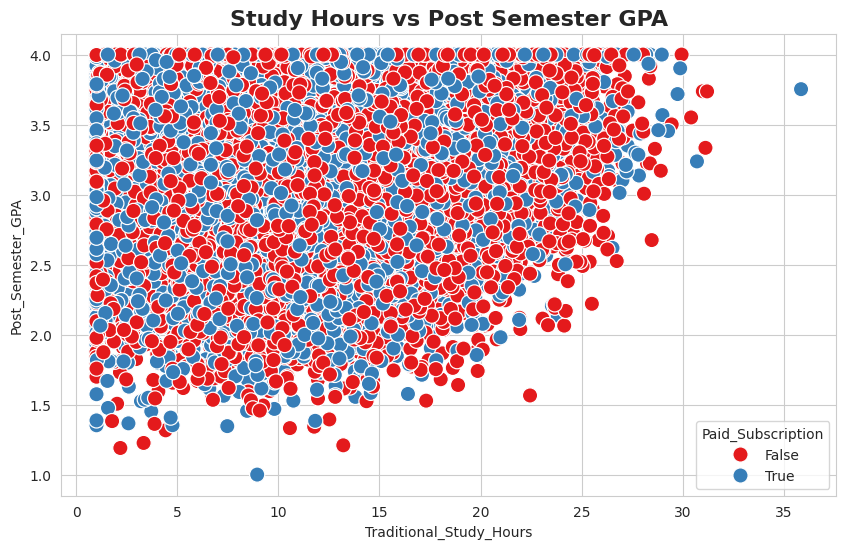

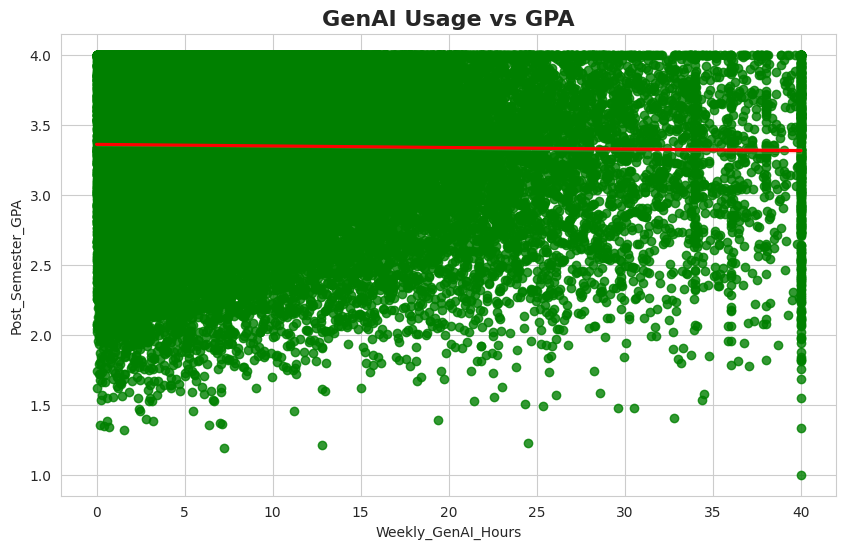

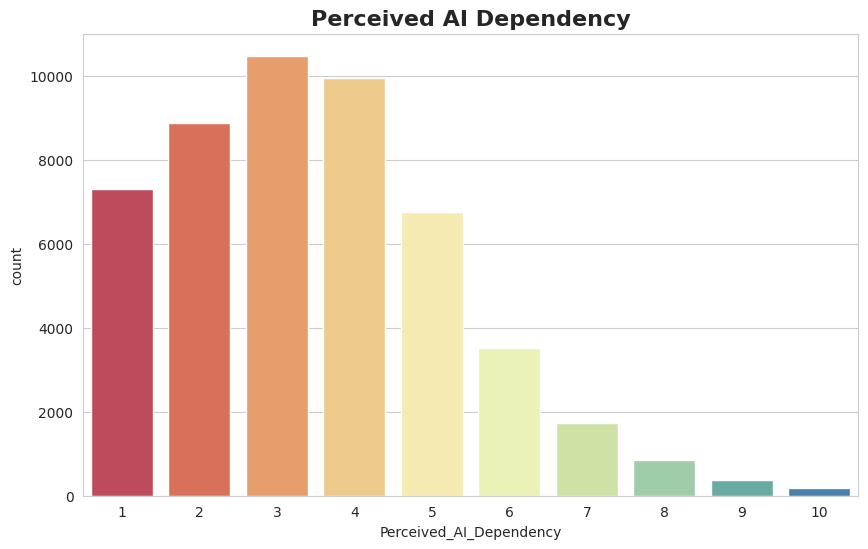

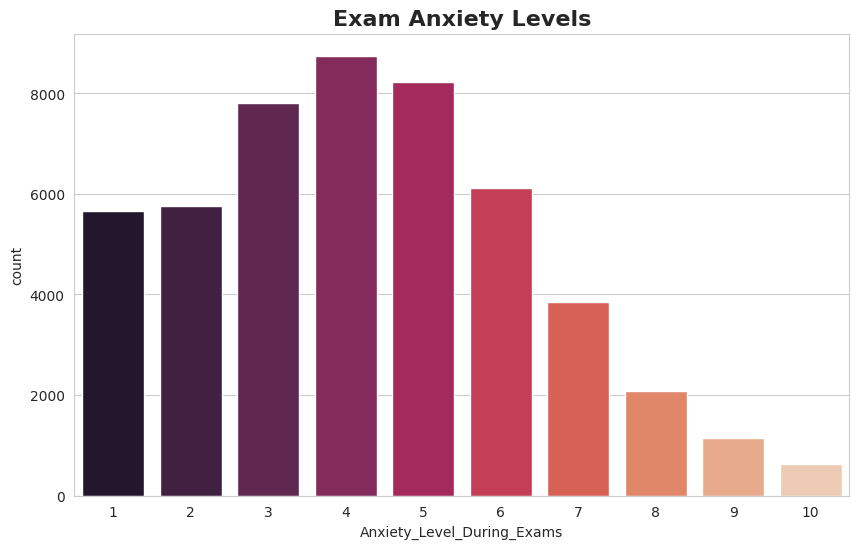

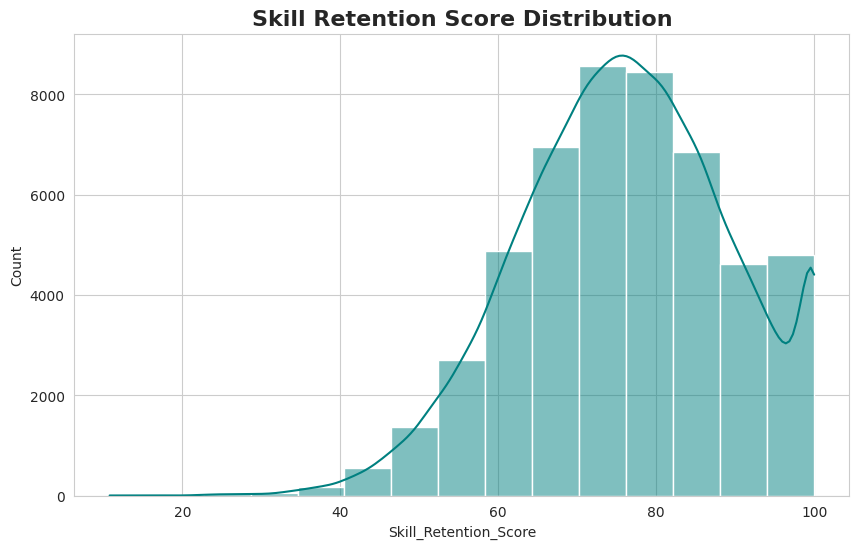

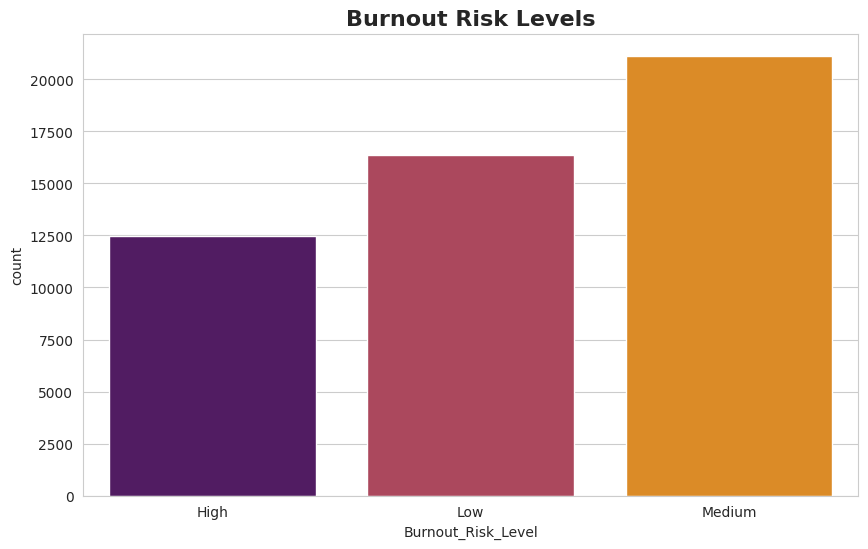

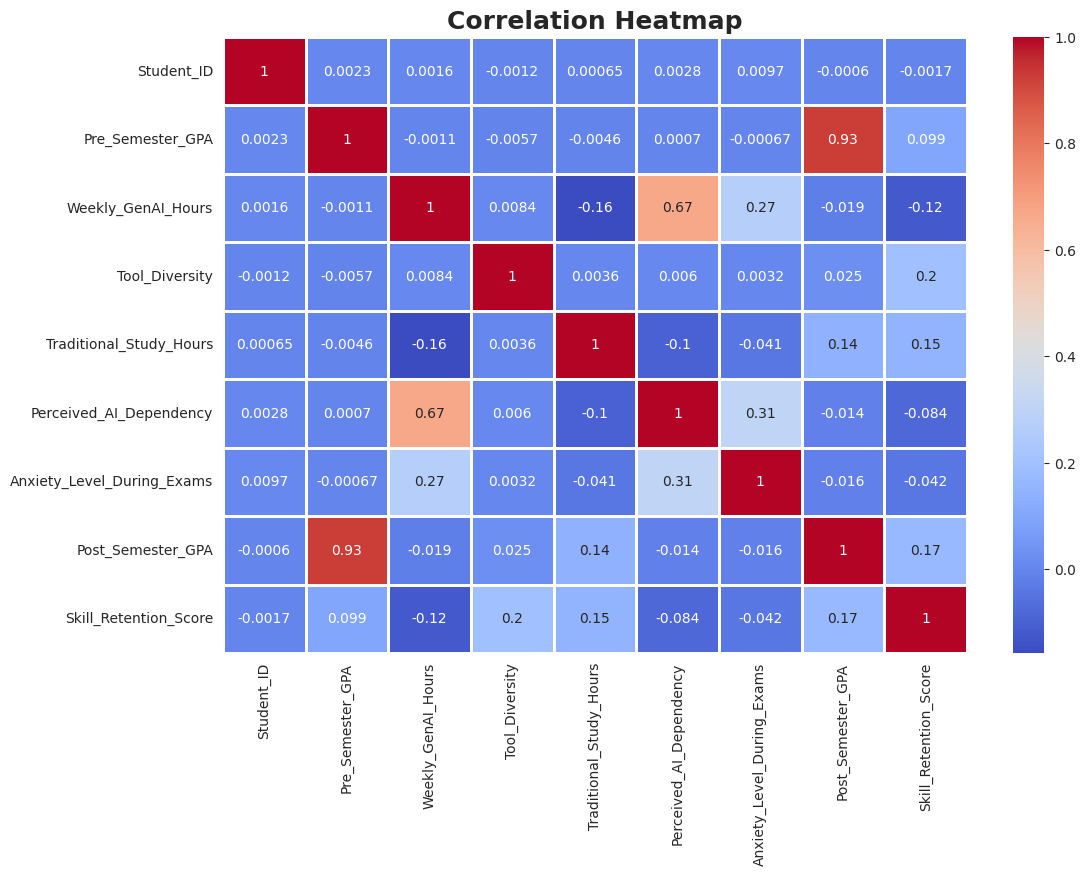

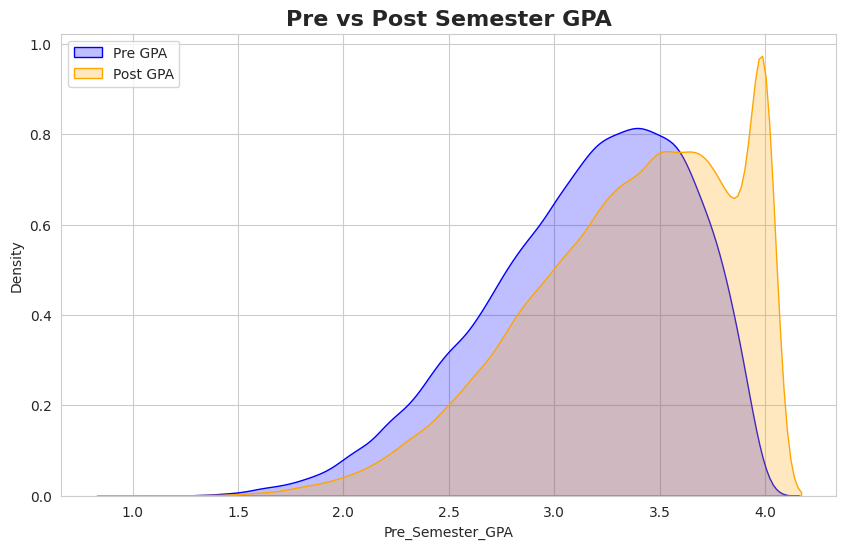

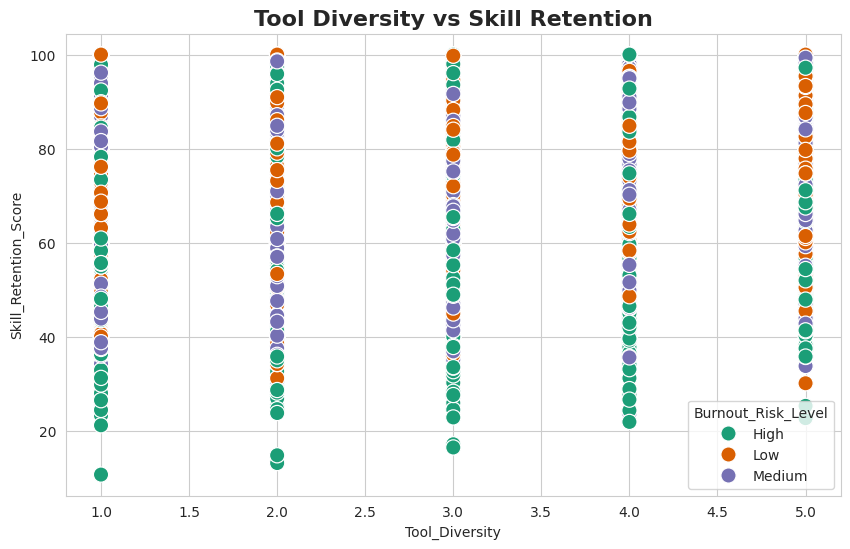

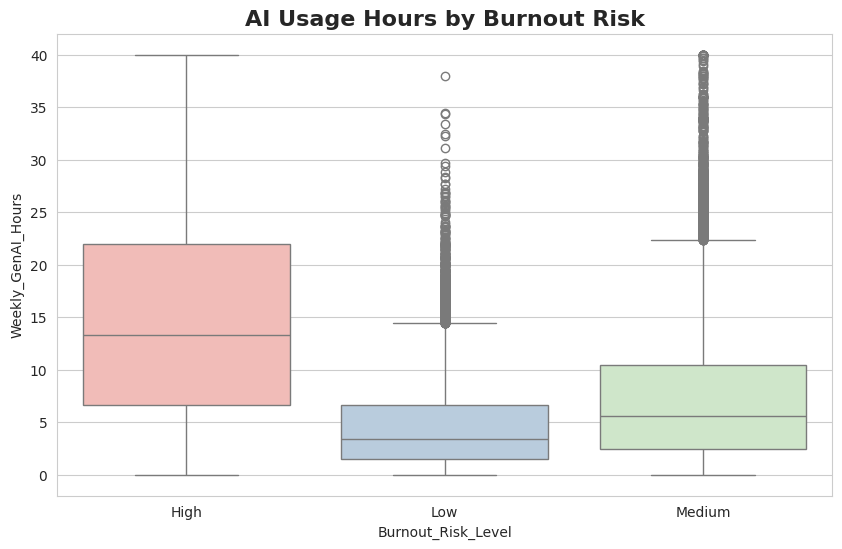

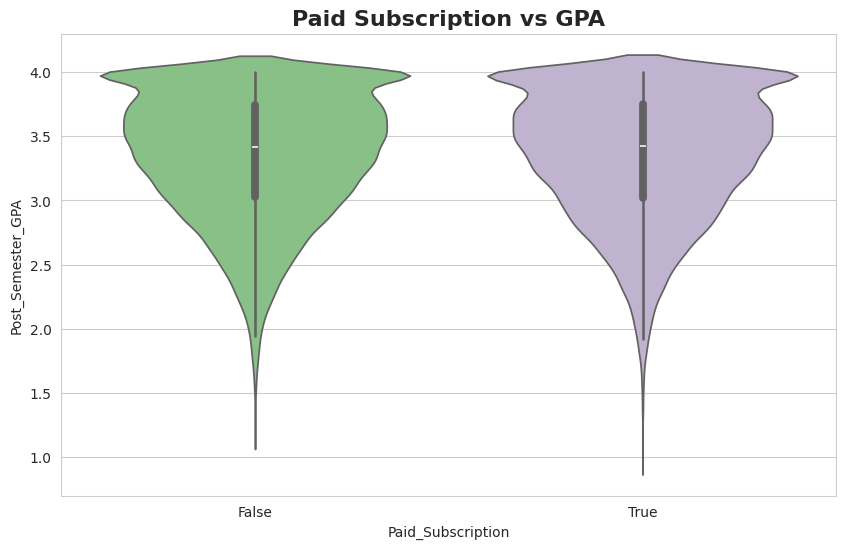

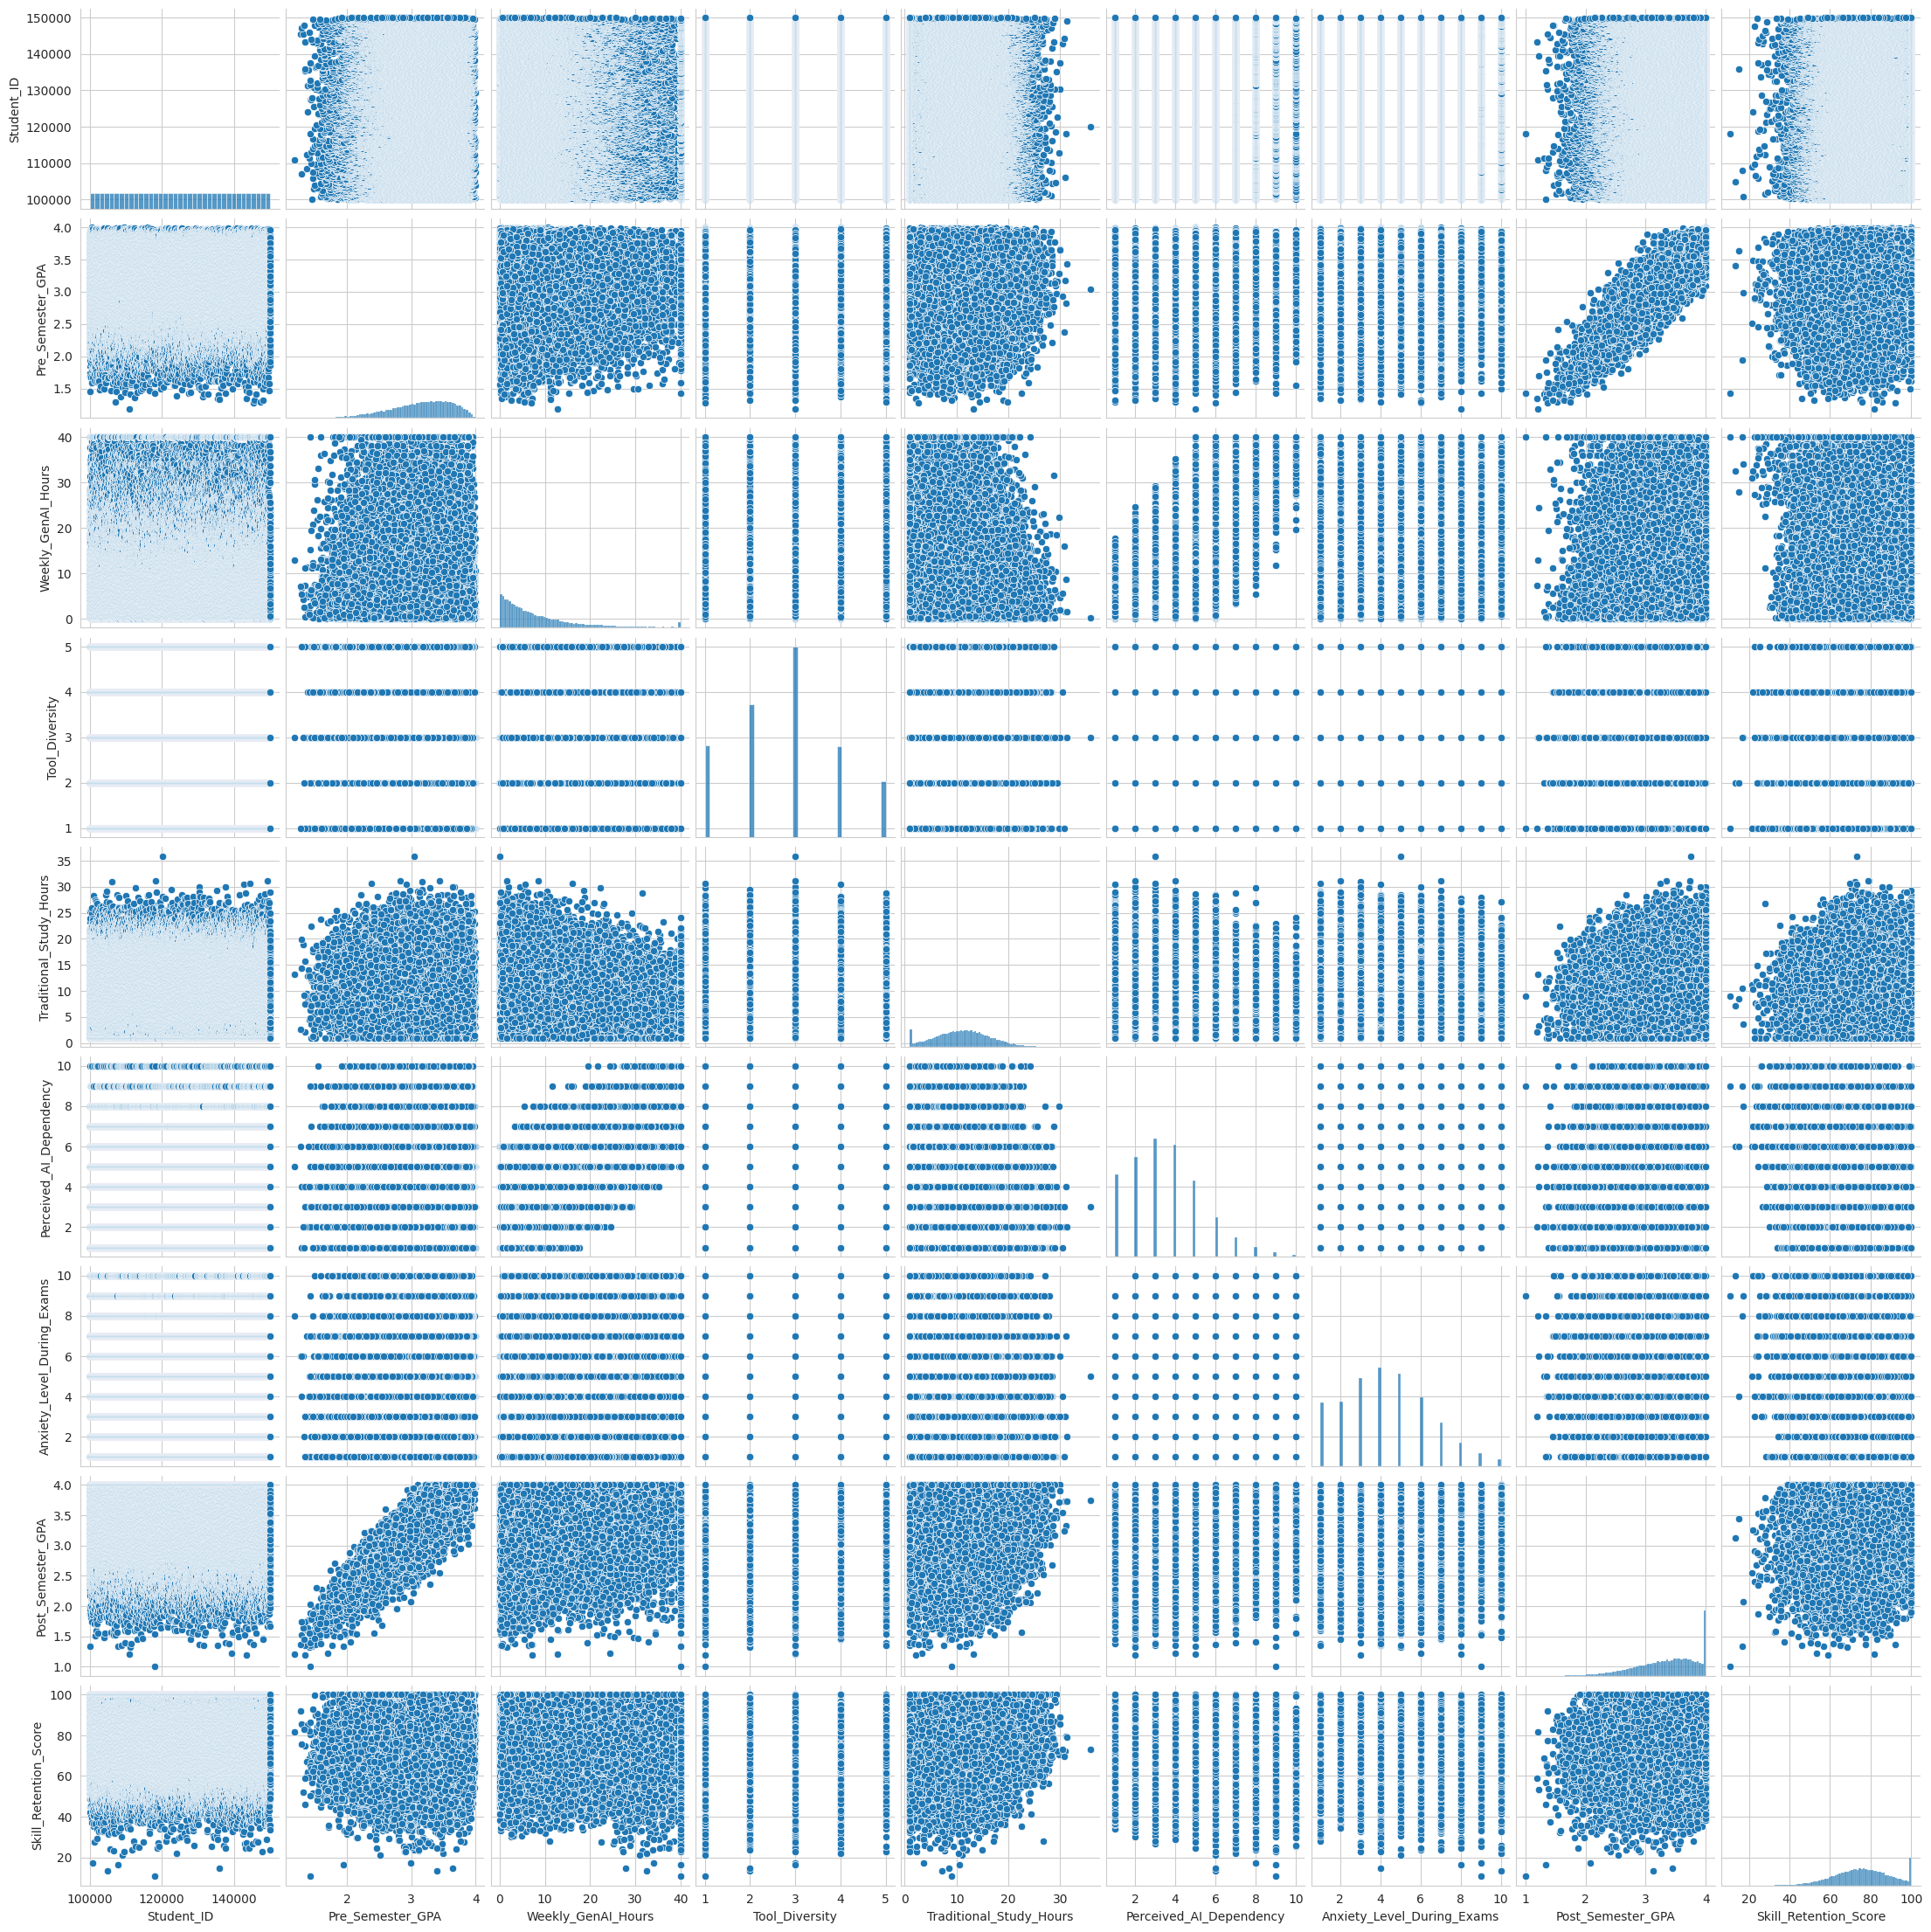

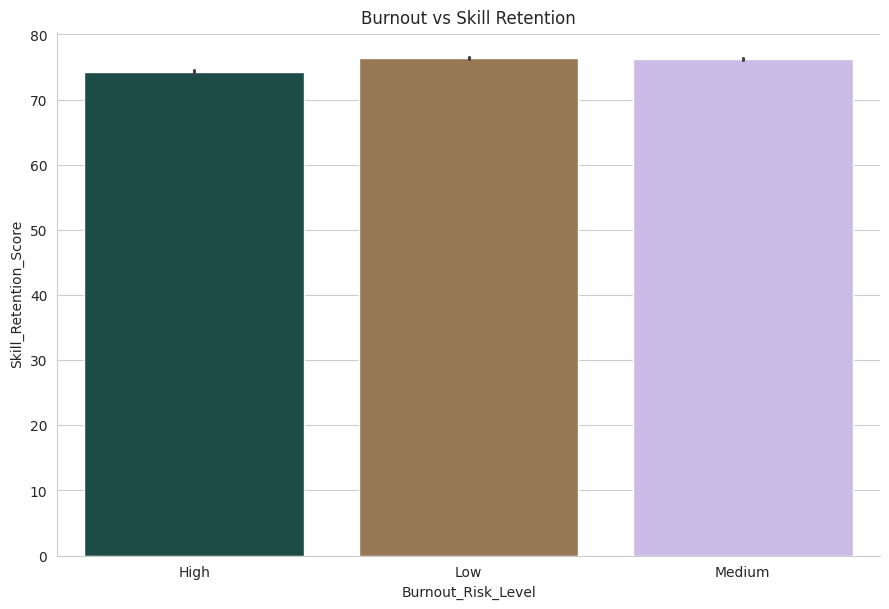

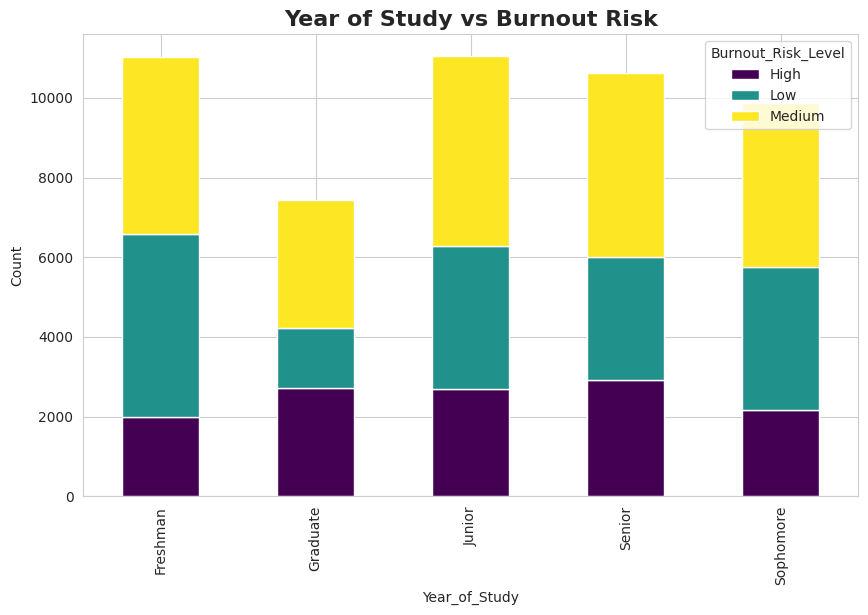


Visualization Completed Successfully!
Total Columns Visualized : 16


In [14]:
import plotly.express as px

# =========================
# BASIC INFORMATION
# =========================
print("Dataset Shape :", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n")
print(df.dtypes)

# =========================
# STYLE SETTINGS
# =========================
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

# =========================
# COLOR PALETTES
# =========================
palette1 = "viridis"
palette2 = "magma"
palette3 = "coolwarm"
palette4 = "Set2"
palette5 = "plasma"

# ============================================================
# 1. DISTRIBUTION OF PRE-SEMESTER GPA
# ============================================================
plt.figure(figsize=(10,6))
sns.histplot(df['Pre_Semester_GPA'], bins=20,
             kde=True, color='royalblue')
plt.title("Distribution of Pre Semester GPA",
          fontsize=16, fontweight='bold')
plt.xlabel("Pre Semester GPA")
plt.ylabel("Count")
plt.show()

# ============================================================
# 2. DISTRIBUTION OF POST-SEMESTER GPA
# ============================================================
plt.figure(figsize=(10,6))
sns.histplot(df['Post_Semester_GPA'],
             bins=20,
             kde=True,
             color='darkorange')
plt.title("Distribution of Post Semester GPA",
          fontsize=16,
          fontweight='bold')
plt.xlabel("Post Semester GPA")
plt.ylabel("Count")
plt.show()

# ============================================================
# 3. MAJOR CATEGORY COUNT
# ============================================================
plt.figure(figsize=(12,6))
sns.countplot(data=df,
              x='Major_Category',
              palette='Set3')

plt.title("Students by Major Category",
          fontsize=16,
          fontweight='bold')

plt.xticks(rotation=45)
plt.show()

# ============================================================
# 4. YEAR OF STUDY DISTRIBUTION
# ============================================================
plt.figure(figsize=(8,5))
sns.countplot(data=df,
              x='Year_of_Study',
              palette='cool')

plt.title("Year of Study Distribution",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# 5. WEEKLY GENAI HOURS
# ============================================================
plt.figure(figsize=(10,6))
sns.boxplot(data=df,
            y='Weekly_GenAI_Hours',
            color='purple')

plt.title("Weekly GenAI Usage Hours",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# 6. PRIMARY USE CASE ANALYSIS
# ============================================================
plt.figure(figsize=(12,6))
sns.countplot(data=df,
              y='Primary_Use_Case',
              palette='rainbow')

plt.title("Primary Use Cases of GenAI",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# 7. PROMPT ENGINEERING SKILL LEVEL
# ============================================================
plt.figure(figsize=(10,6))
sns.countplot(data=df,
              x='Prompt_Engineering_Skill',
              palette='flare')

plt.title("Prompt Engineering Skill Levels",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# 8. PAID SUBSCRIPTION ANALYSIS
# ============================================================
plt.figure(figsize=(6,6))

df['Paid_Subscription'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=['skyblue', 'salmon'],
    explode=[0.02, 0.08],
    shadow=True
)

plt.title("Paid Subscription Usage",
          fontsize=16,
          fontweight='bold')

plt.ylabel("")
plt.show()

# ============================================================
# 9. STUDY HOURS VS POST GPA
# ============================================================
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,
                x='Traditional_Study_Hours',
                y='Post_Semester_GPA',
                hue='Paid_Subscription',
                palette='Set1',
                s=120)

plt.title("Study Hours vs Post Semester GPA",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# 10. GENAI HOURS VS GPA
# ============================================================
plt.figure(figsize=(10,6))
sns.regplot(data=df,
            x='Weekly_GenAI_Hours',
            y='Post_Semester_GPA',
            scatter_kws={'color':'green'},
            line_kws={'color':'red'})

plt.title("GenAI Usage vs GPA",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# 11. AI DEPENDENCY LEVEL
# ============================================================
plt.figure(figsize=(10,6))
sns.countplot(data=df,
              x='Perceived_AI_Dependency',
              palette='Spectral')

plt.title("Perceived AI Dependency",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# 12. EXAM ANXIETY LEVEL
# ============================================================
plt.figure(figsize=(10,6))
sns.countplot(data=df,
              x='Anxiety_Level_During_Exams',
              palette='rocket')

plt.title("Exam Anxiety Levels",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# 13. SKILL RETENTION SCORE DISTRIBUTION
# ============================================================
plt.figure(figsize=(10,6))
sns.histplot(df['Skill_Retention_Score'],
             bins=15,
             kde=True,
             color='teal')

plt.title("Skill Retention Score Distribution",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# 14. BURNOUT RISK LEVEL
# ============================================================
plt.figure(figsize=(10,6))
sns.countplot(data=df,
              x='Burnout_Risk_Level',
              palette='inferno')

plt.title("Burnout Risk Levels",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# 15. CORRELATION HEATMAP
# ============================================================
numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(numeric_cols.corr(),
            annot=True,
            cmap='coolwarm',
            linewidths=1)

plt.title("Correlation Heatmap",
          fontsize=18,
          fontweight='bold')

plt.show()

# ============================================================
# 16. GPA COMPARISON BEFORE & AFTER
# ============================================================
plt.figure(figsize=(10,6))

sns.kdeplot(df['Pre_Semester_GPA'],
            fill=True,
            color='blue',
            label='Pre GPA')

sns.kdeplot(df['Post_Semester_GPA'],
            fill=True,
            color='orange',
            label='Post GPA')

plt.title("Pre vs Post Semester GPA",
          fontsize=16,
          fontweight='bold')

plt.legend()
plt.show()

# ============================================================
# 17. TOOL DIVERSITY VS SKILL RETENTION
# ============================================================
plt.figure(figsize=(10,6))

sns.scatterplot(data=df,
                x='Tool_Diversity',
                y='Skill_Retention_Score',
                hue='Burnout_Risk_Level',
                palette='Dark2',
                s=120)

plt.title("Tool Diversity vs Skill Retention",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# 18. BOXPLOT : AI HOURS BY BURNOUT RISK
# ============================================================
plt.figure(figsize=(10,6))

sns.boxplot(data=df,
            x='Burnout_Risk_Level',
            y='Weekly_GenAI_Hours',
            palette='Pastel1')

plt.title("AI Usage Hours by Burnout Risk",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# 19. INTERACTIVE PLOTLY SCATTER
# ============================================================
fig = px.scatter(
    df,
    x='Weekly_GenAI_Hours',
    y='Post_Semester_GPA',
    color='Burnout_Risk_Level',
    size='Tool_Diversity',
    hover_data=['Major_Category'],
    title='Interactive AI Usage vs GPA'
)

fig.show()

# ============================================================
# 20. INTERACTIVE SUNBURST CHART
# ============================================================
fig2 = px.sunburst(
    df,
    path=['Major_Category',
          'Primary_Use_Case',
          'Burnout_Risk_Level'],
    title='Student AI Usage Hierarchy'
)

fig2.show()

# ============================================================
# 21. VIOLIN PLOT
# ============================================================
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x='Paid_Subscription',
    y='Post_Semester_GPA',
    palette='Accent'
)

plt.title("Paid Subscription vs GPA",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# 22. PAIRPLOT
# ============================================================
sns.pairplot(
    df[numeric_cols.columns],
    palette='husl'
)

plt.show()

# ============================================================
# 23. CATPLOT
# ============================================================
sns.catplot(
    data=df,
    x='Burnout_Risk_Level',
    y='Skill_Retention_Score',
    kind='bar',
    palette='cubehelix',
    height=6,
    aspect=1.5
)

plt.title("Burnout vs Skill Retention")
plt.show()

# ============================================================
# 24. STACKED BAR CHART
# ============================================================
cross_tab = pd.crosstab(
    df['Year_of_Study'],
    df['Burnout_Risk_Level']
)

cross_tab.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    colormap='viridis'
)

plt.title("Year of Study vs Burnout Risk",
          fontsize=16,
          fontweight='bold')

plt.ylabel("Count")
plt.show()

# ============================================================
# 25. FINAL SUMMARY
# ============================================================
print("\nVisualization Completed Successfully!")
print("Total Columns Visualized :", len(df.columns))

## Feature engineering

Dataset Shape : (50000, 16)

Encoded Target Classes:
['High' 'Low' 'Medium']

Training Shape : (40000, 14)
Testing Shape : (10000, 14)


MODEL : Logistic Regression

Accuracy : 0.5212

Classification Report:

              precision    recall  f1-score   support

        High       0.66      0.44      0.53      2497
         Low       0.52      0.47      0.49      3274
      Medium       0.48      0.61      0.54      4229

    accuracy                           0.52     10000
   macro avg       0.55      0.51      0.52     10000
weighted avg       0.54      0.52      0.52     10000



<Figure size 1200x800 with 0 Axes>

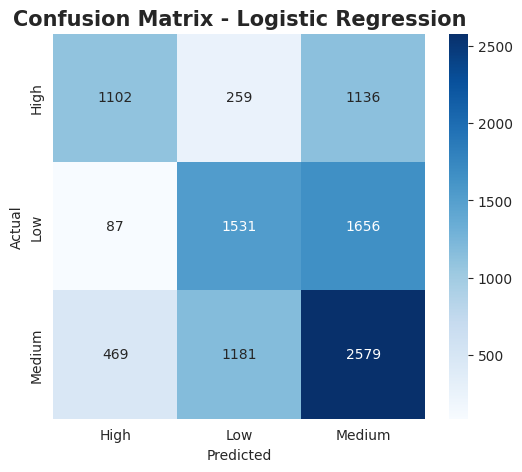


ROC AUC Score : 0.6954


MODEL : Decision Tree

Accuracy : 0.5239

Classification Report:

              precision    recall  f1-score   support

        High       0.67      0.45      0.54      2497
         Low       0.52      0.48      0.50      3274
      Medium       0.48      0.60      0.54      4229

    accuracy                           0.52     10000
   macro avg       0.56      0.51      0.52     10000
weighted avg       0.54      0.52      0.52     10000



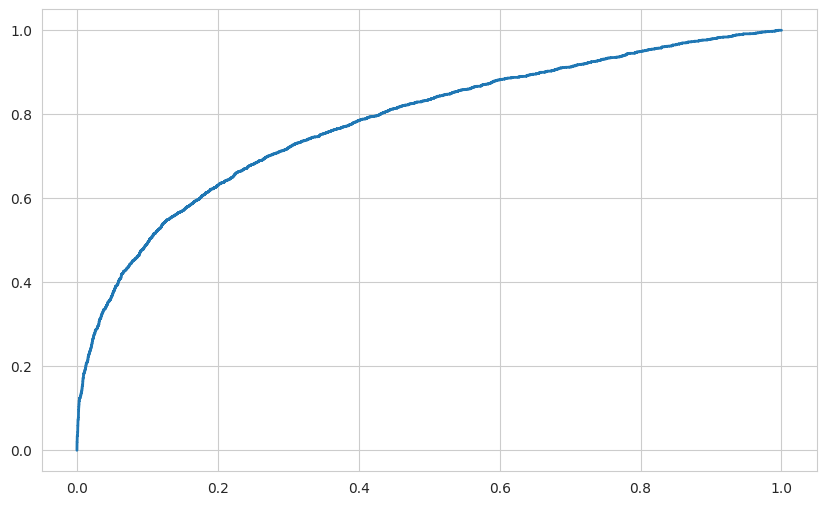

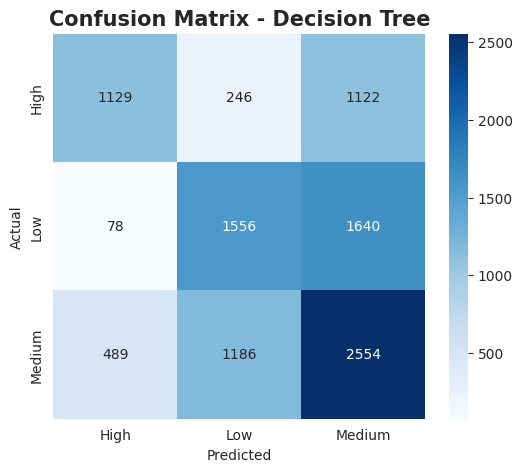


ROC AUC Score : 0.6965


MODEL : Random Forest

Accuracy : 0.5190

Classification Report:

              precision    recall  f1-score   support

        High       0.65      0.47      0.54      2497
         Low       0.52      0.47      0.49      3274
      Medium       0.48      0.59      0.53      4229

    accuracy                           0.52     10000
   macro avg       0.55      0.51      0.52     10000
weighted avg       0.53      0.52      0.52     10000



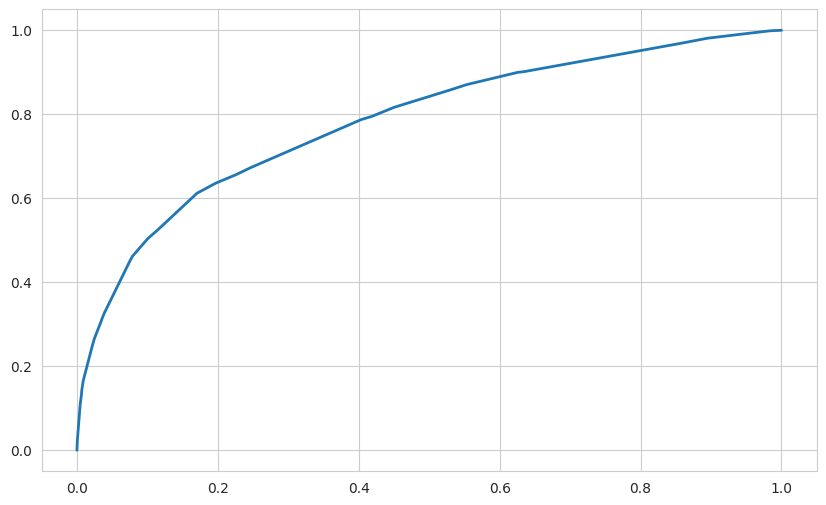

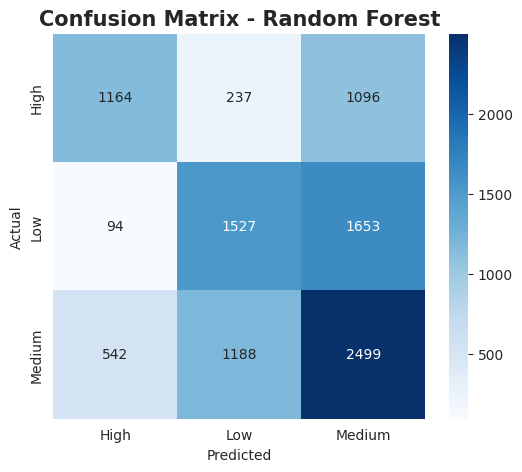


ROC AUC Score : 0.6964


MODEL : KNN

Accuracy : 0.4515

Classification Report:

              precision    recall  f1-score   support

        High       0.47      0.49      0.48      2497
         Low       0.43      0.48      0.46      3274
      Medium       0.46      0.40      0.43      4229

    accuracy                           0.45     10000
   macro avg       0.45      0.46      0.46     10000
weighted avg       0.45      0.45      0.45     10000



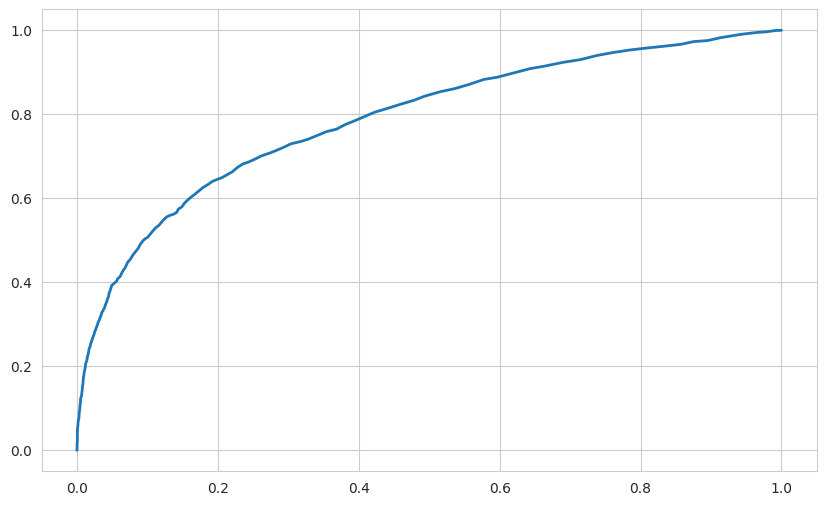

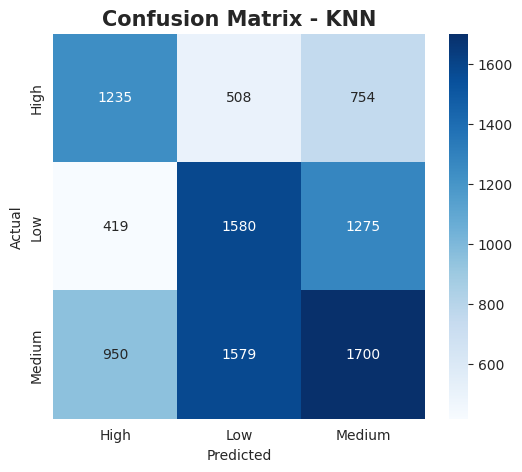


ROC AUC Score : 0.6252


MODEL : SVM

Accuracy : 0.5179

Classification Report:

              precision    recall  f1-score   support

        High       0.70      0.39      0.50      2497
         Low       0.52      0.40      0.46      3274
      Medium       0.47      0.68      0.56      4229

    accuracy                           0.52     10000
   macro avg       0.57      0.49      0.51     10000
weighted avg       0.55      0.52      0.51     10000



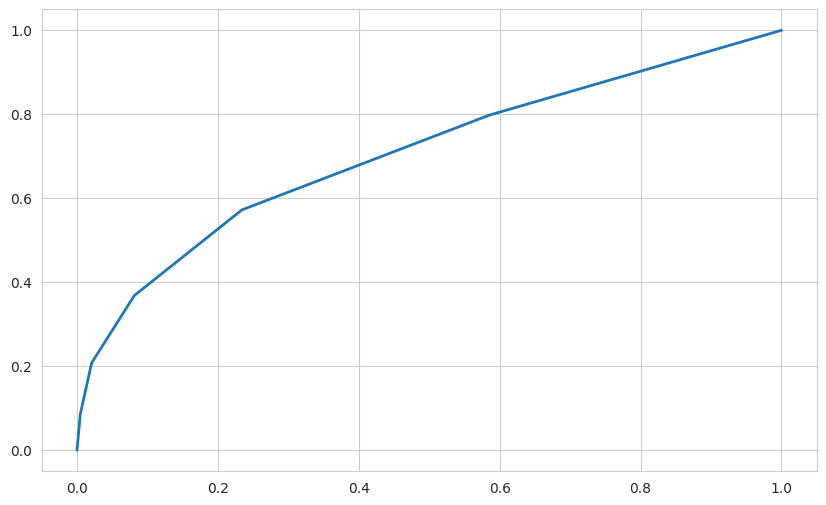

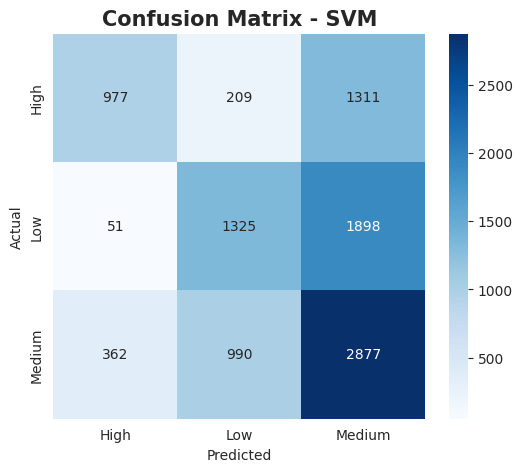


ROC AUC Score : 0.6978


MODEL : Naive Bayes

Accuracy : 0.5084

Classification Report:

              precision    recall  f1-score   support

        High       0.64      0.45      0.53      2497
         Low       0.47      0.70      0.57      3274
      Medium       0.49      0.39      0.44      4229

    accuracy                           0.51     10000
   macro avg       0.53      0.52      0.51     10000
weighted avg       0.52      0.51      0.50     10000



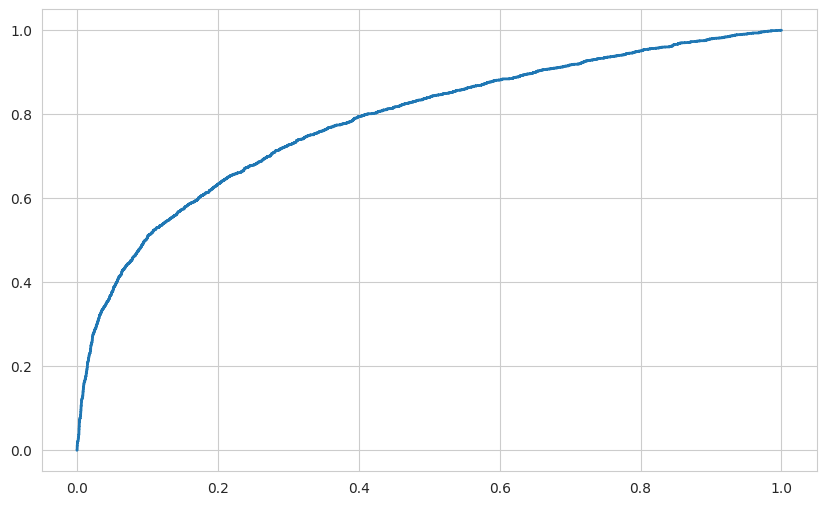

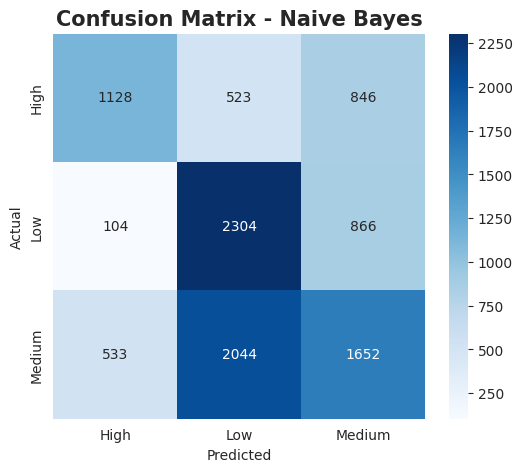


ROC AUC Score : 0.6860


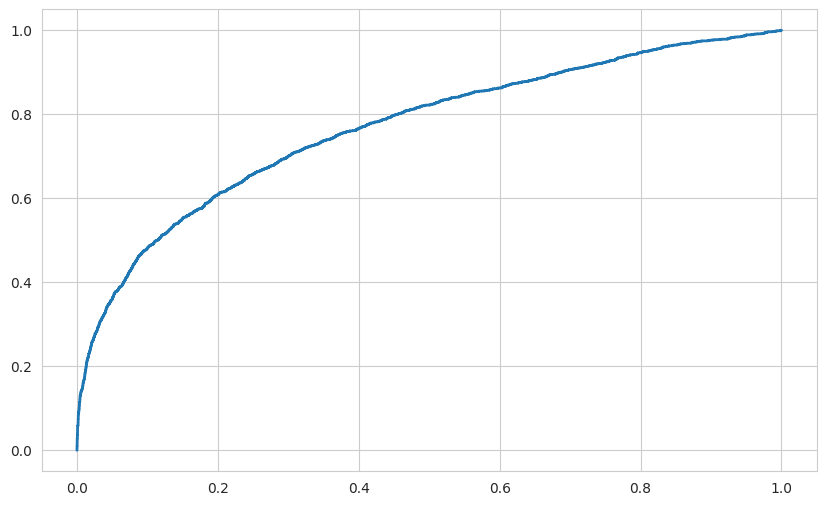

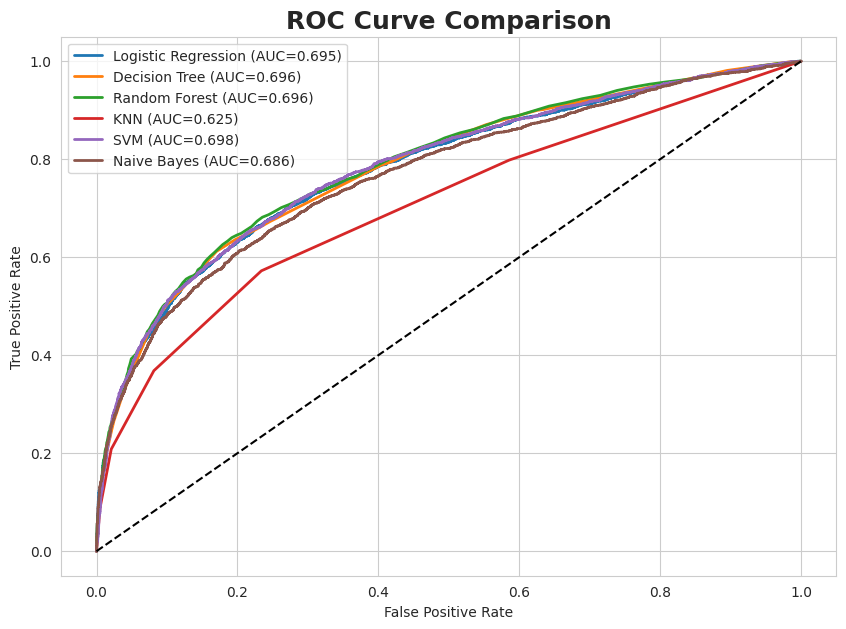



FINAL MODEL COMPARISON
                 Model  Accuracy   ROC_AUC
1        Decision Tree    0.5239  0.696457
0  Logistic Regression    0.5212  0.695374
2        Random Forest    0.5190  0.696447
4                  SVM    0.5179  0.697802
5          Naive Bayes    0.5084  0.686042
3                  KNN    0.4515  0.625150


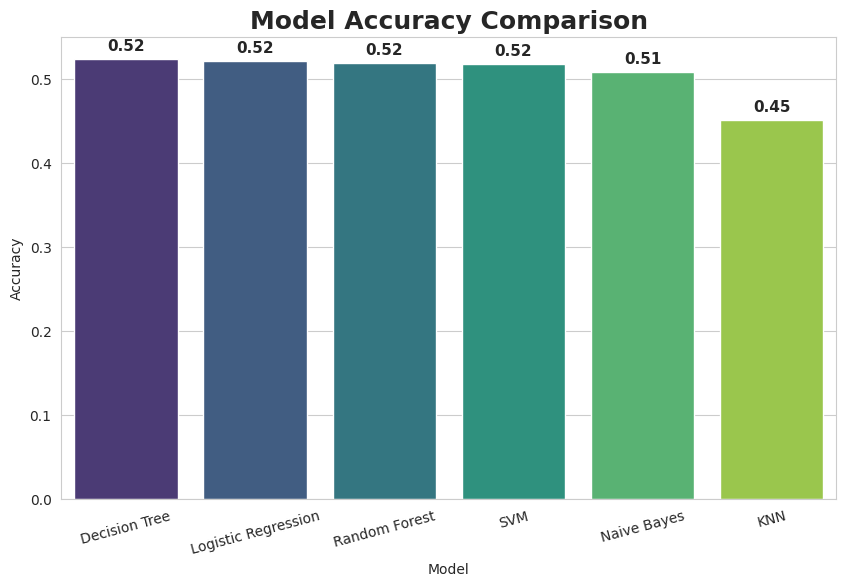


Top Important Features:

                       Feature  Importance
3           Weekly_GenAI_Hours    0.186154
8      Traditional_Study_Hours    0.112924
2             Pre_Semester_GPA    0.111997
13       Skill_Retention_Score    0.109861
12           Post_Semester_GPA    0.104280
9      Perceived_AI_Dependency    0.067477
11  Anxiety_Level_During_Exams    0.059534
6               Tool_Diversity    0.044725
4             Primary_Use_Case    0.044427
0               Major_Category    0.042421
1                Year_of_Study    0.041518
10        Institutional_Policy    0.030397
5     Prompt_Engineering_Skill    0.028849
7            Paid_Subscription    0.015437


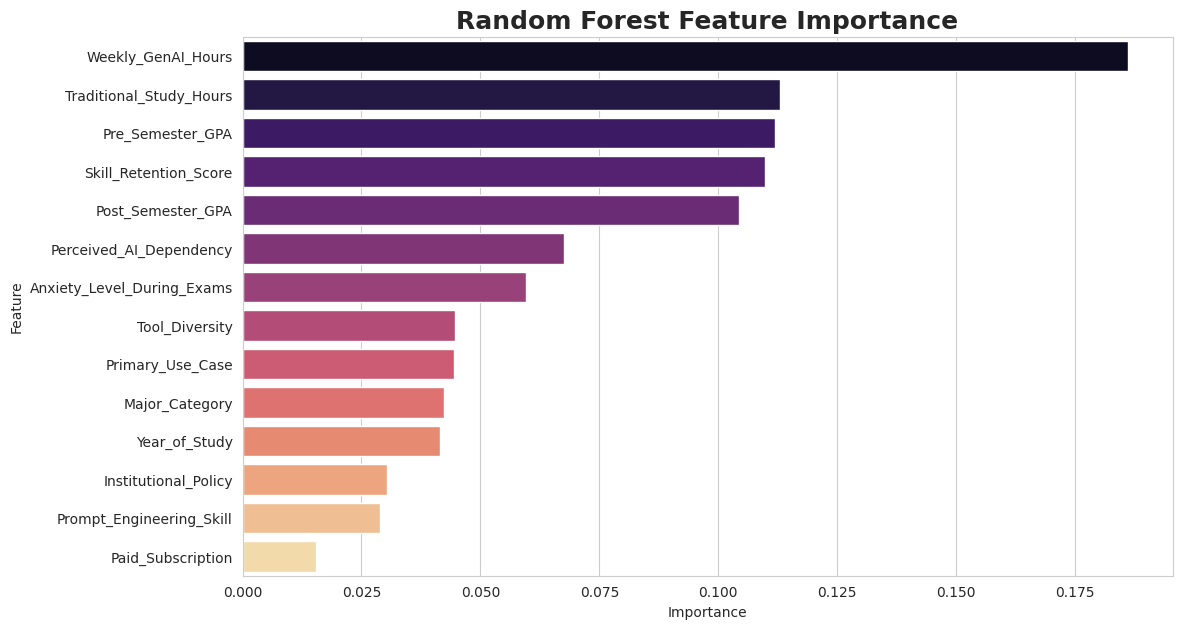



BEST MODEL
Model Name : Decision Tree
Accuracy   : 0.5239
ROC AUC    : 0.6965

Machine Learning Pipeline Completed Successfully!


In [15]:
# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB


print("Dataset Shape :", df.shape)

df = df.drop("Student_ID", axis=1)

# ==========================================================
# TARGET COLUMN
# ==========================================================
# We will predict Burnout Risk Level

target_column = "Burnout_Risk_Level"

X = df.drop(target_column, axis=1)
y = df[target_column]

label_encoders = {}

for column in X.columns:
    
    if X[column].dtype == 'object':
        
        le = LabelEncoder()
        
        X[column] = le.fit_transform(X[column])
        
        label_encoders[column] = le

# Encode target separately
target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)

print("\nEncoded Target Classes:")
print(target_encoder.classes_)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

# ==========================================================
# FEATURE SCALING
# ==========================================================
# Fit scaler ONLY on training data
# Prevents data leakage

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# ==========================================================
# MACHINE LEARNING MODELS
# ==========================================================
models = {
    
    "Logistic Regression": LogisticRegression(max_iter=1000),
    
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    
    "KNN": KNeighborsClassifier(n_neighbors=5),
    
    "SVM": SVC(
        probability=True,
        kernel='rbf',
        random_state=42
    ),
    
    "Naive Bayes": GaussianNB()
}

# ==========================================================
# STORE RESULTS
# ==========================================================
results = []

# ==========================================================
# ROC CURVE FIGURE
# ==========================================================
plt.figure(figsize=(12,8))

# ==========================================================
# TRAIN & EVALUATE MODELS
# ==========================================================
for model_name, model in models.items():
    
    print("\n")
    print("="*60)
    print("MODEL :", model_name)
    print("="*60)
    
    # ======================================================
    # TRAIN MODEL
    # ======================================================
    
    # Use scaled data for models sensitive to scaling
    if model_name in ["Logistic Regression", "KNN", "SVM"]:
        
        model.fit(X_train_scaled, y_train)
        
        y_pred = model.predict(X_test_scaled)
        
        y_prob = model.predict_proba(X_test_scaled)
        
    else:
        
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        
        y_prob = model.predict_proba(X_test)
    
    # ======================================================
    # ACCURACY
    # ======================================================
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"\nAccuracy : {accuracy:.4f}")
    
    # ======================================================
    # CLASSIFICATION REPORT
    # ======================================================
    print("\nClassification Report:\n")
    
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=target_encoder.classes_
        )
    )
    
    # ======================================================
    # CONFUSION MATRIX
    # ======================================================
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(6,5))
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=target_encoder.classes_,
        yticklabels=target_encoder.classes_
    )
    
    plt.title(f"Confusion Matrix - {model_name}",
              fontsize=15,
              fontweight='bold')
    
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    
    plt.show()
    
    # ======================================================
    # ROC AUC SCORE
    # ======================================================
    
    # Multi-class ROC
    
    n_classes = len(np.unique(y))
    
    auc_score = roc_auc_score(
        y_test,
        y_prob,
        multi_class='ovr'
    )
    
    print(f"\nROC AUC Score : {auc_score:.4f}")
    
    # ======================================================
    # ROC CURVE
    # ======================================================
    
    # For multi-class, use one class
    # Example: class 0
    
    fpr, tpr, thresholds = roc_curve(
        (y_test == 0).astype(int),
        y_prob[:, 0]
    )
    
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {auc_score:.3f})"
    )
    
    # ======================================================
    # STORE RESULTS
    # ======================================================
    
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "ROC_AUC": auc_score
    })

# ==========================================================
# FINAL ROC CURVE
# ==========================================================
plt.figure(figsize=(10,7))

for model_name, model in models.items():
    
    if model_name in ["Logistic Regression", "KNN", "SVM"]:
        
        y_prob = model.predict_proba(X_test_scaled)
        
    else:
        
        y_prob = model.predict_proba(X_test)
    
    fpr, tpr, thresholds = roc_curve(
        (y_test == 0).astype(int),
        y_prob[:, 0]
    )
    
    auc_score = roc_auc_score(
        y_test,
        y_prob,
        multi_class='ovr'
    )
    
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC={auc_score:.3f})"
    )

# Random Line
plt.plot([0,1], [0,1], 'k--')

plt.title(
    "ROC Curve Comparison",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(True)

plt.show()

# ==========================================================
# RESULTS DATAFRAME
# ==========================================================
results_df = pd.DataFrame(results)

# ==========================================================
# SORT RESULTS
# ==========================================================
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

# ==========================================================
# DISPLAY RESULTS
# ==========================================================
print("\n")
print("="*60)
print("FINAL MODEL COMPARISON")
print("="*60)

print(results_df)

# ==========================================================
# BARPLOT OF MODEL ACCURACY
# ==========================================================
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.title(
    "Model Accuracy Comparison",
    fontsize=18,
    fontweight='bold'
)

plt.xticks(rotation=15)

for index, row in results_df.iterrows():
    
    plt.text(
        x=list(results_df.index).index(index),
        y=row["Accuracy"] + 0.01,
        s=f"{row['Accuracy']:.2f}",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.show()

# ==========================================================
# FEATURE IMPORTANCE (RANDOM FOREST)
# ==========================================================
rf_model = models["Random Forest"]

feature_importance = pd.DataFrame({
    
    "Feature": X.columns,
    
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop Important Features:\n")
print(feature_importance)

# ==========================================================
# FEATURE IMPORTANCE PLOT
# ==========================================================
plt.figure(figsize=(12,7))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    palette="magma"
)

plt.title(
    "Random Forest Feature Importance",
    fontsize=18,
    fontweight='bold'
)

plt.show()

# ==========================================================
# BEST MODEL
# ==========================================================
best_model = results_df.iloc[0]

print("\n")
print("="*60)
print("BEST MODEL")
print("="*60)

print(f"Model Name : {best_model['Model']}")
print(f"Accuracy   : {best_model['Accuracy']:.4f}")
print(f"ROC AUC    : {best_model['ROC_AUC']:.4f}")

# ==========================================================
# END
# ==========================================================
print("\nMachine Learning Pipeline Completed Successfully!")

## Thank you..pls upvote!!!!!!!!!!!